# Alan Brosnan Final Part 3

Note: This is an individual project. Name: Alan Brosnan EID: anb5226

# Section 1: Review of Part 2 

Review of 2:

My system models cooling of a turbine blade using a forced convection ODE. The temperature changes based on heat loss to surrounding air, which varies slowly over time. In Part 2, the problem was solved using the Backward Euler method. Because this method is implicit, each time step required solving an equation using Newton-Raphson iteration. The system is stiff because it has two very different time scales, First is has a very fast cooling rate due to a large convection coefficient, and secondly a much slower change in the ambient temperature. This large separation causes explicit methods like Euler Forward to become unstable unless very small time steps are used, which motivates using implicit methods instead.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
#Brief recap of your problem and basic implicit solver
#State the stiffness parameter and why the problem is stiff
#PUT THE IMPLICIT SOLVER

#Parameters:
conv_h = 1500
t_start = 0
t_end = 10
T_initial = 1000
dt = 0.01

#ambeint forcing
def T_inf(t):
    return 300 + 10*np.sin(0.01*t)
#Guiding ODE
def dTdt(T, t):
    return -conv_h * (T - T_inf(t))

#stiffness stuff
tau_fast = 1 / conv_h
tau_slow = 1 / 0.01 # forcing time scale
stiffness_ratio = tau_slow / tau_fast
print("Fast time scale:", tau_fast)
print("Slow time scale:", tau_slow)
print("Stiffness ratio:", stiffness_ratio)

#write the residual function for specific problem
def residual(T_new, T_old, t_new, dt):
    return (1 + conv_h*dt)*T_new - T_old - conv_h*dt*T_inf(t_new)
#analytically derive g prime
def residual_derivative(dt):
    return 1 + conv_h*dt

Fast time scale: 0.0006666666666666666
Slow time scale: 100.0
Stiffness ratio: 150000.0


In [2]:
#Backward Eulers with Newton Raphson:
#newton_raphson function
def newton_raphson(F, F_prime, x0, tol=1e-8, max_iter=10):
    x = x0
    for k in range(max_iter):
        x_new = x - F(x) / F_prime(x)
        if abs(x_new - x) < tol:
            return x_new, k+1, True
        x = x_new
    return x, max_iter, False

def backward_euler_step(T_old, t_old, h):
    t_new = t_old + h
    def F(T):
        return T - T_old - h * (-conv_h * (T - T_inf(t_new)))
    def F_prime(T):
        return 1 + conv_h * h
    T0 = T_old
    T_new, iters, ok = newton_raphson(F, F_prime, T0)
    return T_new, iters, ok

t_values = np.arange(t_start, t_end + dt, dt)
T_values = np.zeros(len(t_values))
iters_list = []

T_values[0] = T_initial

for i in range(1, len(t_values)):
    T_values[i], iters, _ = backward_euler_step(T_values[i-1], t_values[i], dt)
    iters_list.append(iters)

# Section 2: Newton-Raphson Damping Implementation

Explaining damping and line search:

Damping improves the stability of a function by scaling the Newton Raphson by a factor between 0 and 1. In doing this the damping method can check whether the residual is reduced or not. If it's found that the residual is not reduced, the value of damping gets halfed until theres a safe enough step that reduces the residual. Essentially, it checks that newton raphson is not overshooting the solution.

Line Search is the method that the damping coefficient uses. Essentially, line searching works by moving along the newton direction for a step size that guarentees improvement. The goal being that each step size reduces the residual to prevent divergence and converge to the solution.

In [3]:
def damped_newton_raphson(y_n, t_next, h, g_func, g_prime_func, tol=1e-8, max_iter=20, alpha_min=1e-4):
    y_guess = y_n
    for k in range(max_iter):
        g = g_func(y_guess, y_n, t_next, h)
        if abs(g) < tol:
            return y_guess, k, True
        g_prime = g_prime_func(h)
        delta = -g / g_prime
        # Line search for damping factor
        alpha = 1.0
        g_current = abs(g)
        for _ in range(10):  # Max 10 backtracking steps
            y_new = y_guess + alpha * delta
            g_new = abs(g_func(y_new, y_n, t_next, h))
            if g_new < g_current:  # Sufficient decrease
                break
            alpha = alpha / 2.0
            # FIX: track damping usage for analysis
            if alpha < 1.0 and stats is not None:
                stats["damping_used"] += 1
            if alpha < alpha_min:
                print(f"Warning: alpha too small at iter {k}")
                return y_guess, k, False
        y_guess = y_new
    return y_guess, max_iter, False


In [4]:
#Demonstration where damping helps (e.g., very large initial h)
# large step size test
h_test = 2.0
t_test = 1.0
T_old = 1000

# basic NR
y_basic, it_basic, ok_basic = backward_euler_step(T_old, t_test, h_test) #running my old newton raphson from part 2

# damped NR
y_damped, it_damped, ok_damped = damped_newton_raphson(T_old, t_test, h_test,residual, residual_derivative)

print("Basic Newton Raphson:")
print("Converged:", ok_basic)
print("Iterations:", it_basic)
print("Result:", y_basic)

print("\nDamped Newton Raphson:")
print("Converged:", ok_damped)
print("Iterations:", it_damped)
print("Result:", y_damped)

Basic Newton Raphson:
Converged: True
Iterations: 2
Result: 300.53311063181434

Damped Newton Raphson:
Converged: True
Iterations: 1
Result: 300.333220593144


Comparing basic NR to damped NR convergence:

There is an issue in quantifying how damped NR convergence would help with my system of equations. Since my system is linear, the regular newton raphson will converge in one to two iterations, due to the linearity of my system. This shows that regardless of if i use Damped Newton Raphson or Basic Newton Raphson it will still converge in 1 to 2 iterations no matter how big the h step is. However, despite this the damped newton was still more efficient, converging in one less step than the regular newton raphson

# Section 3: Adaptive Step Size Implementation

Explanation of step-doubling error estimation:

Step double error estimation works by comparing a single big step to two smaller half steps. Fixed step size can be inadquate for balancing both cost efficiency and accuracy. For example when an h size is too large the method may fail to capture the accuracy of the desired function. However, when the h size is too small the method will conduct unnecessary computations that cause an increased computational cost for marginal accuracy improvements. However, the step double approach makes the h adaptive to balance both computational cost and accuracy by using the big step and two half steps to estimate which has a lower error while not sacrificing unnecessary computational time.


In [5]:
#Implementation with clear comments showing:
#Single step of size h
#Two half-steps of size h/2
#Error estimation and step size adjustment

def estimate_error_step_doubling(T_n, t_n, h):
    # ONE full step using backward euler
    T_full, it1, _ = backward_euler_step(T_n, t_n, h)
    # TWO half steps using backward euler
    T_half_1, it2, _ = backward_euler_step(T_n, t_n, h/2)
    T_half_2, it3, _ = backward_euler_step(T_half_1, t_n + h/2, h/2)
    # error estimate for steps (relative error stabilizes stiffness issues)
    err = abs(T_half_2 - T_full) / (abs(T_half_2) + 1e-10)
    # total cost for analysis later
    total_iters = it1 + it2 + it3
    return T_full, T_half_2, err, total_iters

#computing new step size:
def adaptive_step(T_n, t_n, h, tol):
    eps = 1e-12
    safety = 0.9
    h_min = 1e-6
    h_max = 1.0
    T_full, T_half, err, iters = estimate_error_step_doubling(T_n, t_n, h)
    # prevent division issues
    err = max(err, eps)
    # compute new step size
    h_new = h * np.sqrt(tol / err)
    h_new = safety * h_new
    # safety bounds
    h_new = max(h_min, min(h_max, h_new))
    # accept/reject
    if err < tol:
        return T_half, h, h_new, True, iters, err   # ACCEPT
    else:
        return T_n, h, h_new, False, iters, err    # REJECT

#which step to use
def adaptive_solver(T0, t0, t_end, h0, tol):
    max_steps = 10000
    step_count = 0
    h_min = 1e-6
    h_max = 1.0
    t_vals = [t0]
    T_vals = [T0]
    h_vals = []
    err_vals = []
    t = t0
    T = T0
    h = h0
    accepted = 0
    rejected = 0
    total_iters = 0
    consecutive_rejects = 0
    while t < t_end - 1e-12 and step_count < max_steps:
        step_count += 1
        # prevent overshooting final time
        if t + h > t_end:
            h = t_end - t
        T_new, h_used, h_new, ok, iters, err = adaptive_step(T, t, h, tol)
        total_iters += int(iters)
        if ok:
            # ACCEPT STEP
            t += max(h_used, 1e-12)
            T = T_new
            t_vals.append(t)
            T_vals.append(T)
            h_vals.append(h_used)
            err_vals.append(err)
            h = h_new
            accepted += 1
            consecutive_rejects = 0
        else:
            # REJECT STEP → stronger shrink
            h = max(h * 0.5, h_min)
            rejected += 1
            consecutive_rejects += 1
            if consecutive_rejects >= 5:
                h = max(h * 0.1, h_min)
                consecutive_rejects = 0
            if h <= h_min:
                h = h_min
    stats = {"accepted": accepted, "rejected": rejected, "total_iters": total_iters}

    return np.array(t_vals), np.array(T_vals), np.array(h_vals), np.array(err_vals), stats

# Section 4: Performance Analysis

In [6]:
#Fixed vs. Adaptive comparison:
#Same target accuracy: compare total steps, function evaluations
#Same step budget: compare final accuracy

#FIXED STEP BACKWARD EULER SOLUTION
t_fixed = np.arange(t_start, t_end + dt, dt)
T_fixed = np.zeros(len(t_fixed))
T_fixed[0] = T_initial

fixed_iters = 0

for i in range(1, len(t_fixed)):
    T_fixed[i], iters, _ = backward_euler_step(T_fixed[i-1], t_fixed[i], dt)
    fixed_iters += iters

#ADAPTIVE SOLUTION
t_adapt, T_adapt, h_hist, err_hist, stats = adaptive_solver(T_initial, t_start, t_end, h0=0.1, tol=1e-4)
# safety fallback (prevents crash cascade)
if len(t_adapt) < 2:
    print("WARNING: Adaptive solver produced no usable trajectory.")
    t_adapt = np.array([t_start, t_end])
    T_adapt = np.array([T_initial, T_initial])
    h_hist = np.array([0.1])
    err_hist = np.array([0.0])
    stats = {"accepted": 0, "rejected": 0, "total_iters": 0}

# 3. COMPUTATIONAL COST COMPARISON
adaptive_iters = stats["total_iters"]

print("COMPUTATIONAL COST")
print("Fixed Backward Euler:")
print("  Steps:", len(t_fixed))
print("  Newton iterations:", fixed_iters)

print("\nAdaptive Backward Euler:")
print("  Steps:", len(t_adapt))
print("  Accepted:", stats["accepted"])
print("  Rejected:", stats["rejected"])
print("  Newton iterations:", adaptive_iters)


# 4. ACCURACY COMPARISON (FINAL VALUE ERROR)
final_error = abs(T_fixed[-1] - T_adapt[-1])

print("\nACCURACY COMPARISON")
print("Final fixed T:", T_fixed[-1])
print("Final adaptive T:", T_adapt[-1])
print("Absolute difference:", final_error)

print("\nApprox function evaluations:")
print("Fixed:", fixed_iters)
print("Adaptive:", adaptive_iters)



COMPUTATIONAL COST
Fixed Backward Euler:
  Steps: 1001
  Newton iterations: 2000

Adaptive Backward Euler:
  Steps: 149
  Accepted: 148
  Rejected: 10
  Newton iterations: 948

ACCURACY COMPARISON
Final fixed T: 300.99926283231775
Final adaptive T: 300.9982678191526
Absolute difference: 0.0009950131651521588

Approx function evaluations:
Fixed: 2000
Adaptive: 948


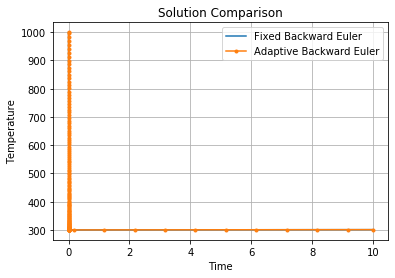

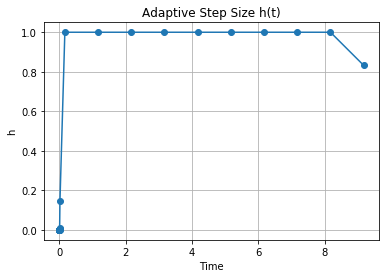

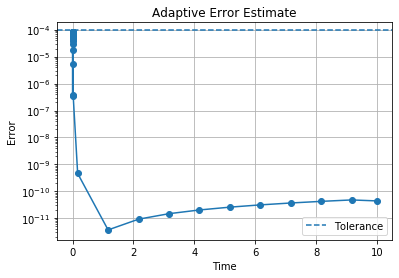

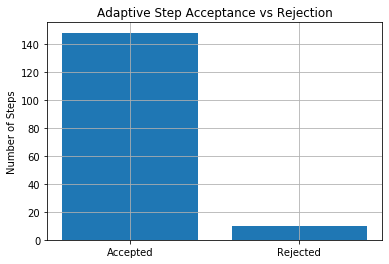

In [7]:
#Plots:
plt.figure()
plt.plot(t_fixed, T_fixed, label="Fixed Backward Euler")
plt.plot(t_adapt, T_adapt, '-o', markersize=3, label="Adaptive Backward Euler")
plt.title("Solution Comparison")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.grid()
plt.show()

# --- Adaptive step size history ---
plt.figure()
plt.plot(t_adapt[:-1], h_hist, '-o')
plt.title("Adaptive Step Size h(t)")
plt.xlabel("Time")
plt.ylabel("h")
plt.grid()
plt.show()

# --- Adaptive error evolution ---
plt.figure()
plt.semilogy(t_adapt[1:], err_hist, '-o')
plt.axhline(y=1e-4, linestyle='--', label="Tolerance")
plt.title("Adaptive Error Estimate")
plt.xlabel("Time")
plt.ylabel("Error")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.bar(["Accepted", "Rejected"], [stats["accepted"], stats["rejected"]])
plt.title("Adaptive Step Acceptance vs Rejection")
plt.ylabel("Number of Steps")
plt.grid()
plt.show()

In [8]:
#summary of information presented:
print("\nSUMMARY TABLE")
print(f"{'Method':<15}{'Steps':<10}{'Iterations':<15}")
print("-"*40)
print(f"{'Fixed':<15}{len(t_fixed):<10}{fixed_iters:<15}")
print(f"{'Adaptive':<15}{len(t_adapt):<10}{adaptive_iters:<15}")


SUMMARY TABLE
Method         Steps     Iterations     
----------------------------------------
Fixed          1001      2000           
Adaptive       149       948            


Explanation of section 4:
    
In this section I test the performance of fixed backward euler with newton raphson compared to my adaptive step size solver. The fixed backward euler method works by using a fixed predetermined time step size, however my adaptive step size solver can change the time step to provide a level of accuracy and computational efficiency that cannot be compromised for with the fixed step solver. Shown in the data taken from the run times, the backward euler method with Newton Raphson implementation takes significantly more steps to reach the same level of accuracy then the adaptive method did. Additionally, a mark of an effective adaptive step size was the efficiency of it's step size accuracy, being accepted more than it was rejected. This thus showed that it was beneficial in decreasing the functions required to reach accurate levels. 

As for the graphs in the Solution comparison we can see that the graphs perfectly cover each other up. This is good as it shows that both methods are able to reach the solution, the only difference is that the adaptive method did it more efficiently. In the h size graph you can see the oscillations between the step sizes as it adapts and changes to provide computational efficiency. The adaptive error estimate graph shows the tolerance line between what's seen as a tolerable solution. The error starts high then drops low and stays low while the h step is low, however when the h step rises to be closer to 1 the error will rise a bit. This is fine since it's still below the tolerance line, and it actually demonstrates the tradeoff between efficiency and accuracy. The bar graph demonstrates the number of accepted iterations vs rejected iterations, showing the large number of accepted steps shows that the adaptive step size was effective. 

Regarding the comparison of fixed vs adaptive steps it's shown that the adaptive takes less steps and runs less iterations to reach an accurate answer because of it's ability to adapt it steps. 

# Section 5: Robustness Testing

In [9]:
#Test with very large initial h (e.g., h₀ = 1.0)
t_big_h, T_big_h, h_hist_big, err_hist_big, stats_big_h = adaptive_solver(T_initial, t_start, t_end, h0=1.0, tol=1e-4)

print("=== LARGE h0 TEST ===")
print("Accepted:", stats_big_h["accepted"])
print("Rejected:", stats_big_h["rejected"])
print("Final step size:", h_hist_big[-1] if len(h_hist_big) > 0 else "N/A")

=== LARGE h0 TEST ===
Accepted: 147
Rejected: 10
Final step size: 0.9456687021045003


In [10]:
#Test with very tight tolerance (e.g., tol = 10⁻6)
t_strict, T_strict, h_hist_strict, err_hist_strict, stats_strict = adaptive_solver(T_initial, t_start, t_end, h0=0.1, tol=1e-6)

print("\n=== TIGHT TOLERANCE TEST ===")
print("Accepted:", stats_strict["accepted"])
print("Rejected:", stats_strict["rejected"])
print("Final step size:", h_hist_strict[-1] if len(h_hist_strict) > 0 else "N/A")


=== TIGHT TOLERANCE TEST ===
Accepted: 1357
Rejected: 10
Final step size: 0.9311244463300383


In [11]:
# FIX: additional tolerance case for robustness trend validation
t_mid, T_mid, h_hist_mid, err_hist_mid, stats_mid = adaptive_solver(T_initial, t_start, t_end, h0=0.1, tol=1e-3)

print("\n=== MID TOLERANCE TEST (1e-3) ===")
print("Accepted:", stats_mid["accepted"])
print("Rejected:", stats_mid["rejected"])
print("Final step size:", h_hist_mid[-1] if len(h_hist_mid) > 0 else "N/A")


=== MID TOLERANCE TEST (1e-3) ===
Accepted: 55
Rejected: 8
Final step size: 0.930875401788807


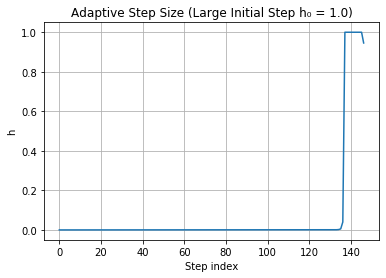

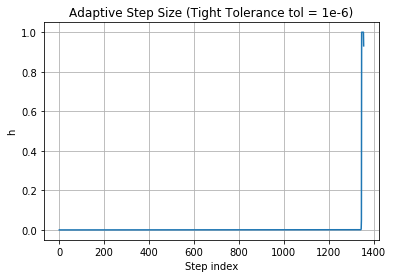

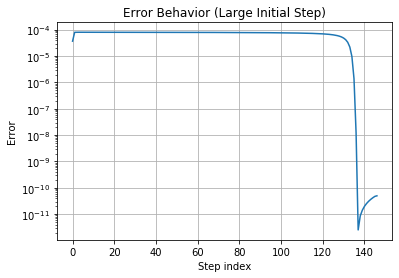

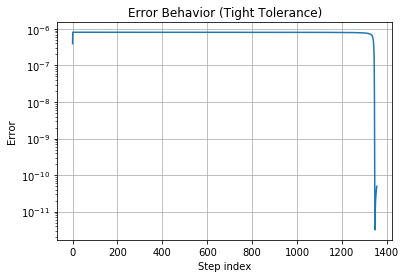

In [12]:
#Show that adaptive solver handles both gracefully

err_plot_strict = np.array(err_hist_strict)
err_plot_strict = np.maximum(err_plot_strict, 1e-14)

err_plot_big = np.array(err_hist_big)
err_plot_big = np.maximum(err_plot_big, 1e-14)


# Step size: large h0 test
plt.figure()
plt.plot(h_hist_big)
plt.title("Adaptive Step Size (Large Initial Step h₀ = 1.0)")
plt.xlabel("Step index")
plt.ylabel("h")
plt.grid()
plt.show()


# Step size: tight tolerance test
plt.figure()
plt.plot(h_hist_strict)
plt.title("Adaptive Step Size (Tight Tolerance tol = 1e-6)")
plt.xlabel("Step index")
plt.ylabel("h")
plt.grid()
plt.show()


# Error: large h0 test
plt.figure()
plt.semilogy(err_plot_big)
plt.title("Error Behavior (Large Initial Step)")
plt.xlabel("Step index")
plt.ylabel("Error")
plt.grid()
plt.show()


# Error: tight tolerance test
plt.figure()
plt.semilogy(err_plot_strict)
plt.title("Error Behavior (Tight Tolerance)")
plt.xlabel("Step index")
plt.ylabel("Error")
plt.grid()
plt.show()

Explanation of section 5:

Robustness is a test of more extreme conditions to evaluate how effective the adaptive step size method is. To do this I tested a large intial step where it must then evaluate and adapt from the large initial step. I also tested a tight tolerance to force it to adapt and scale accuracy over step size more. In the graphs above this is demonstrated where with the high step size the adaptive immediately uses smaller steps to adjust and compensate for the initial high step size before then going back to larger step sizes (h=1) and plateauing. For the tight tolerance this is also shown as the adaptive size step must use small h sizes to reach an accurate measure to fall under tolerance. The inverse of these can be seen in the error behavior as when the small h step sizes are used for the initial high step size the solver first reduces the step size to bring the error below the tolerance, and once the solution stabilizes, it increases the step size again while keeping the error small. This is also shown in the tight tolerance error graph as the use of smaller step sizes reduces the error below the tolerance, after which the solver increases the step size again.  

# Section 6: Conclusions

When is damping necessary?

Damping is necessary when Newton Raphson may become unstable and unable to converge.With large step sizes and poor intial guesses Newton Raphson runs the risk of overshooting. In using damping it ensures that Newton Raphson is consistently moving to converging and decreasing the residual to avoid divergence. Damping wasn't necessary to my application because my system was linear but it can be useful to reaching stability in nonlinear cases.


When are adaptive step sizes worth the complexity?

Adaptive step sizes are useful when the function changes over time and shows a lot of oscillations. Adaptive steps allow for larger step sizes in smoother regions and smaller step sizes in oscillatory regions. In doing this, adaptive step sizes allow a more efficient balance between computational cost and accuracy.



Key lessons learned

Damping and adaptive step sizing are important to make solvers more efficient and reliable. Despite implicit methods being good with stiff equations, damping and adaptive step sizing can provide a new balance between computational cost and efficiency if used correctly. Despite my case not necessarily needing adaptive step sizing or damping, in many more complicated applications these methods would be helpful, especially when working with varying functions that have a lot of differenet shapes/slopes. 

# BONUS 1

PI Controller Adaptive Solver
-----------------------------
Accepted steps: 441
Rejected steps: 421
Total Newton iterations: 5172


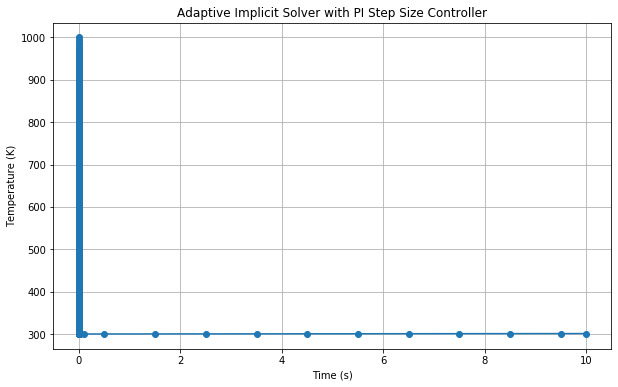

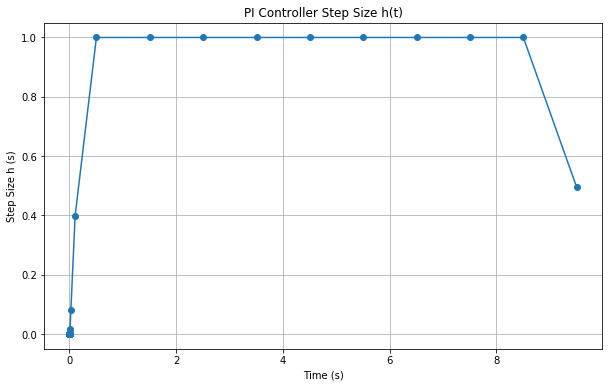

In [13]:
# Adaptive step size implicit solver using PI step size controller
def adaptive_solver_PI(T0, t0, tf, h0, tol=1e-4, h_min=1e-8, h_max=1.0):
    t_vals = [t0]
    T_vals = [T0]
    h_vals = []
    error_vals = []
    accept_reject = []
    t = t0
    T = T0
    h = h0
    accepted = 0
    rejected = 0
    total_iters = 0
    # Previous error for PI controller
    err_prev = tol
    # PI controller constants
    kP = 0.7
    kI = 0.4
    safety = 0.9
    while t < tf:
        if t + h > tf:
            h = tf - t
        # Estimate error using step doubling
        T_full, T_half, err, iters = estimate_error_step_doubling(T, t, h)
        total_iters += iters
        # Avoid division by zero
        if err < 1e-14:
            err = 1e-14
        # PI controller step size formula
        h_new = h * (tol / err)**kP * (err_prev / err)**kI
        h_new = safety * h_new
        # Limit h variability
        h_new = max(0.2 * h, min(5.0 * h, h_new))
        # Enforce min and max step size
        h_new = max(h_min, min(h_max, h_new))
        if err < tol:
            # Accept step and use more accurate two-half-step result
            t += h
            T = T_half
            t_vals.append(t)
            T_vals.append(T)
            h_vals.append(h)
            error_vals.append(err)
            accept_reject.append(1)
            accepted += 1
            err_prev = err
            h = h_new
        else:
            # Reject step and retry with smaller h
            rejected += 1
            accept_reject.append(0)
            h = h_new
    stats = {"accepted": accepted,"rejected": rejected,"total_iters": total_iters}
    return np.array(t_vals), np.array(T_vals), np.array(h_vals), np.array(error_vals), accept_reject, stats
# Run PI adaptive solver
t_PI, T_PI, h_PI, err_PI, ar_PI, stats_PI = adaptive_solver_PI(T_initial, t_start, t_end, h0=0.1, tol=1e-4)

print("PI Controller Adaptive Solver")
print("-----------------------------")
print(f"Accepted steps: {stats_PI['accepted']}")
print(f"Rejected steps: {stats_PI['rejected']}")
print(f"Total Newton iterations: {stats_PI['total_iters']}")

# Plot PI adaptive solution
plt.figure(figsize=(10,6))
plt.plot(t_PI, T_PI, marker='o')
plt.xlabel("Time (s)")
plt.ylabel("Temperature (K)")
plt.title("Adaptive Implicit Solver with PI Step Size Controller")
plt.grid(True)
plt.show()

# Plot PI step size history
plt.figure(figsize=(10,6))
plt.plot(t_PI[:-1], h_PI, marker='o')
plt.xlabel("Time (s)")
plt.ylabel("Step Size h (s)")
plt.title("PI Controller Step Size h(t)")
plt.grid(True)
plt.show()

In this bonus section I implement an adaptive implicit solver using a PI step size controller. Instead of using a fixed step size, the algorithm adjusts h based on the estimated error from step doubling. The PI controller uses both the current and previous error to update the step size more smoothly and avoid large jumps. Each step is either accepted or rejected depending on if the error is below the tolerance, and if accepted the solution advances using the more accurate result. This helps improve efficiency by taking larger steps when the solution is smooth and smaller steps when needed for accuracy, while still staying stable for the stiff system.

# BONUS 2 RK4

In [14]:
def embedded_RK2_step(T_n, t_n, h):
    k1 = dTdt(T_n, t_n)
    T_predict = T_n + h * k1
    k2 = dTdt(T_predict, t_n + h)
    # RK2 update
    T_RK2 = T_n + (h / 2) * (k1 + k2)
    # error estimate (difference between predictor and corrector)
    err = abs(T_RK2 - T_predict) / max(abs(T_RK2), 1e-8)
    return T_RK2, err
# Adaptive RK2 solver
def adaptive_RK2_solver(T0, t0, tf, h0, tol=1e-4, h_min=1e-8, h_max=1.0):
    t_vals = [t0]
    T_vals = [T0]
    h_vals = []
    err_vals = []
    accept_reject = []
    t = t0
    T = T0
    h = h0
    accepted = 0
    rejected = 0
    function_evals = 0
    safety = 0.9
    while t < tf:
        if t + h > tf:
            h = tf - t
        T_new, err = embedded_RK2_step(T, t, h)
        function_evals += 2
        # FIX: prevent numerical blow-up
        err = max(err, 1e-14)
        # RK2 is order 2 → exponent 1/3
        h_new = safety * h * (tol / err) ** (1/3)
        # clamp step size changes
        h_new = max(0.2 * h, min(5.0 * h, h_new))
        h_new = max(h_min, min(h_max, h_new))
        if err < tol:
            # accept step
            t += h
            T = T_new
            t_vals.append(t)
            T_vals.append(T)
            h_vals.append(h)
            err_vals.append(err)
            accept_reject.append(1)
            accepted += 1
            h = h_new
        else:
            # reject step
            accept_reject.append(0)
            rejected += 1
            h = h_new
    stats = {"accepted": accepted,"rejected": rejected,"function_evals": function_evals}
    return np.array(t_vals), np.array(T_vals), np.array(h_vals), np.array(err_vals), accept_reject, stats

In [15]:
t_RK2, T_RK2, h_RK2, err_RK2, ar_RK2, stats_RK2 = adaptive_RK2_solver(T_initial, t_start, t_end, h0=0.1, tol=1e-4)

print("Embedded RK2 Solver Results")
print("---------------------------")
print("Accepted steps:", stats_RK2["accepted"])
print("Rejected steps:", stats_RK2["rejected"])
print("Function evaluations:", stats_RK2["function_evals"])

Embedded RK2 Solver Results
---------------------------
Accepted steps: 7703
Rejected steps: 9
Function evaluations: 15424


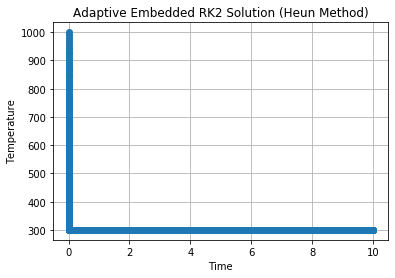

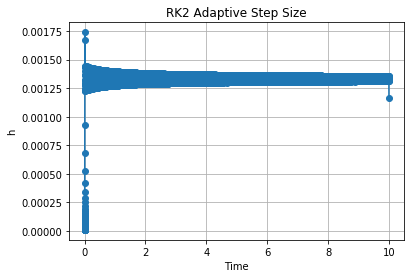

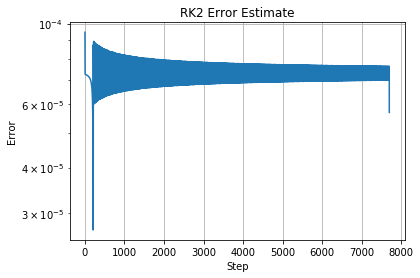

In [16]:
plt.figure()
plt.plot(t_RK2, T_RK2, marker='o')
plt.title("Adaptive Embedded RK2 Solution (Heun Method)")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.grid()
plt.show()

plt.figure()
plt.plot(t_RK2[:-1], h_RK2, marker='o')
plt.title("RK2 Adaptive Step Size")
plt.xlabel("Time")
plt.ylabel("h")
plt.grid()
plt.show()

plt.figure()
plt.semilogy(err_RK2)
plt.title("RK2 Error Estimate")
plt.xlabel("Step")
plt.ylabel("Error")
plt.grid()
plt.show()

For comparison, I also implement an adaptive RK2 method using an embedded error estimate. The error is found by comparing the predictor and corrector steps, and then used to adjust the step size. Steps are accepted or rejected based on the tolerance, similar to the implicit method. However, since RK2 is explicit, it needs more function evaluations and ends up taking more steps, making it less efficient for this stiff problem compared to the implicit solver.